# 5. Rによる空間データの処理・可視化の基本

## 5.6 sfパッケージによる空間データ処理の実例

In [18]:
library(sf)
library(NipponMap)
library(RColorBrewer)

In [ ]:
# Read prefecture polygons in Japan
shp <- system.file("shapes/jpn.shp", package="NipponMap")[1]
pref<- read_sf(shp)

Warning message in CPL_read_ogr(dsn, layer, query, as.character(options), quiet, :
“GDAL Message 1: /usr/local/lib/R/site-library/NipponMap/shapes/jpn.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.”


In [20]:
print(pref)

Simple feature collection with 47 features and 5 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 127.6461 ymin: 26.0709 xmax: 148.8678 ymax: 45.5331
CRS:           NA
# A tibble: 47 × 6
   SP_ID jiscode name      population region                            geometry
   <chr> <chr>   <chr>          <dbl> <chr>                       <MULTIPOLYGON>
 1 1     01      Hokkaido     5506419 Hokkaido (((139.7707 42.3018, 139.8711 42…
 2 2     02      Aomori       1373339 Tohoku   (((140.8727 40.48187, 140.6595 4…
 3 3     03      Iwate        1330147 Tohoku   (((140.7862 39.85982, 140.8199 3…
 4 4     04      Miyagi       2348165 Tohoku   (((140.2802 38.01415, 140.2802 3…
 5 5     05      Akita        1085997 Tohoku   (((140.7895 39.86026, 140.8253 3…
 6 6     06      Yamagata     1168924 Tohoku   (((140.2802 38.01415, 140.2799 3…
 7 7     07      Fukushima    2029064 Tohoku   (((140.2799 37.9721, 140.2799 37…
 8 8     08      Ibaraki      2969770 Kanto    (((139.7322 

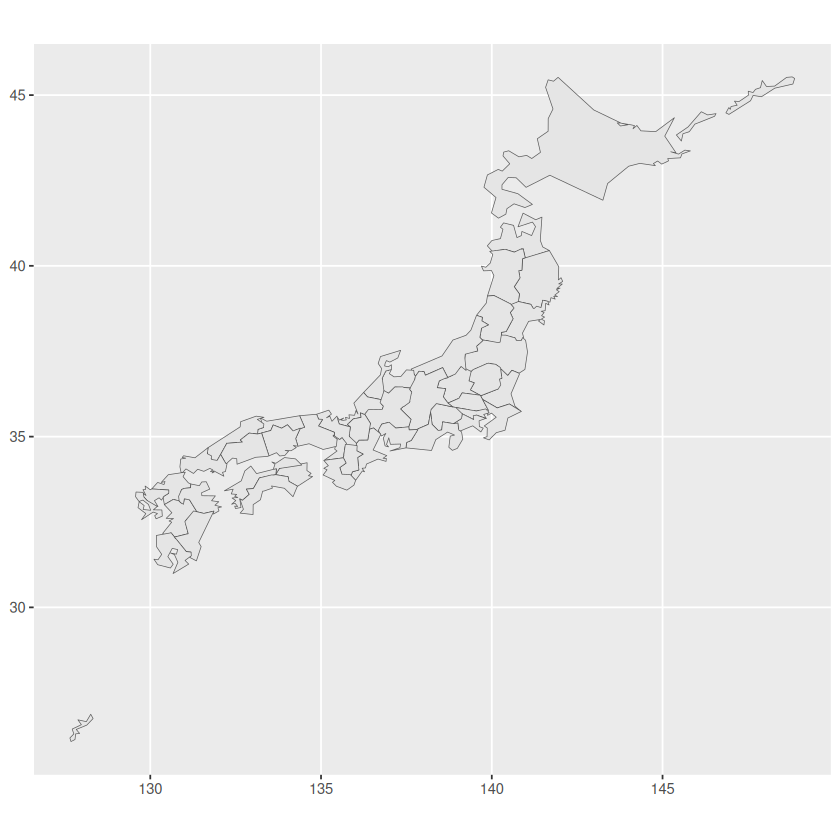

In [21]:
library(ggplot2) # ggplot2 パッケージを読み込み（グラフ作成ライブラリ）
# pref の sf オブジェクトを土台にして地図を描画
# geom_sf() で MULTIPOLYGON を地図としてプロット
ggplot(pref) + geom_sf()

In [ ]:
# Define CRS (Coordinate reference system)
st_crs(pref)

Coordinate Reference System: NA

In [23]:
st_crs(pref) <- 4326
st_crs(pref)

Coordinate Reference System:
  User input: EPSG:4326 
  wkt:
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]],
        AXIS["geodetic longitude (Lon)",east,
            ORDER[2],
            ANGLEUNIT["degree",0.0174532925199433]],
    USAGE[
        SCOPE["Horizon

In [ ]:
# Projection transformation
pref_tr <- st_transform(pref, crs=6677)
st_coordinates(st_centroid(pref_tr))

Warning message:
“st_centroid assumes attributes are constant over geometries”


X,Y
242138.2892,832555.8500
84655.7095,532108.5734
131703.1173,399919.8404
96017.9602,273316.1844
48881.5628,416347.1935
23755.3191,271399.0833
34266.1553,153839.0704
44215.9529,37128.0710
-871.9157,76479.3353
-76310.4859,56936.7880


## 5.7 sfパッケージによる地図化の実例

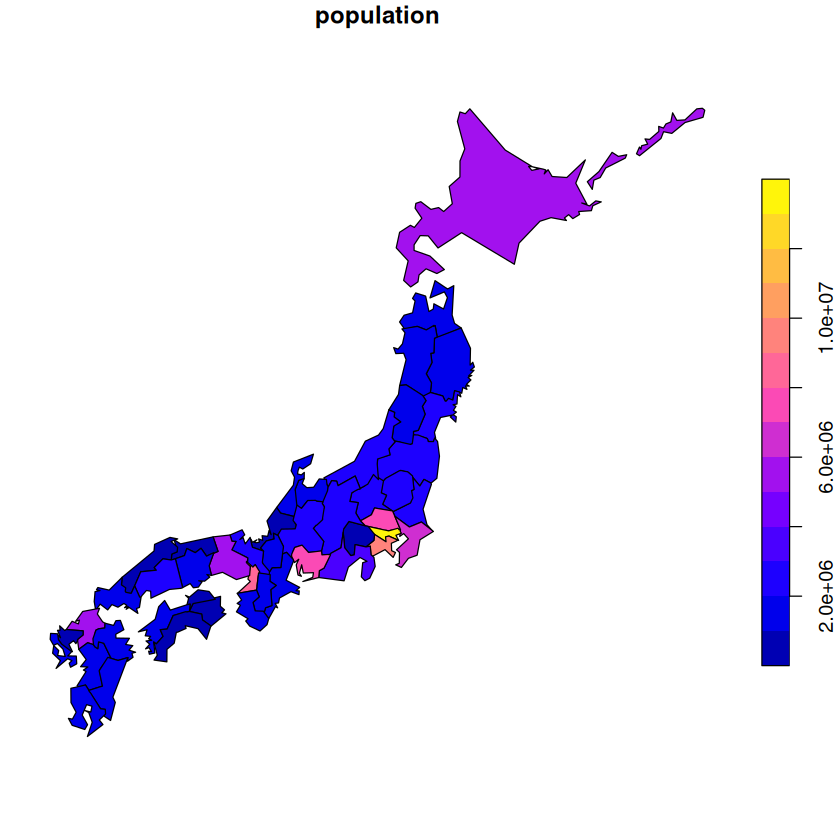

In [ ]:
# Maping
pref2 <- pref[pref$name != "Okinawa",]
plot(pref2[, "population"])

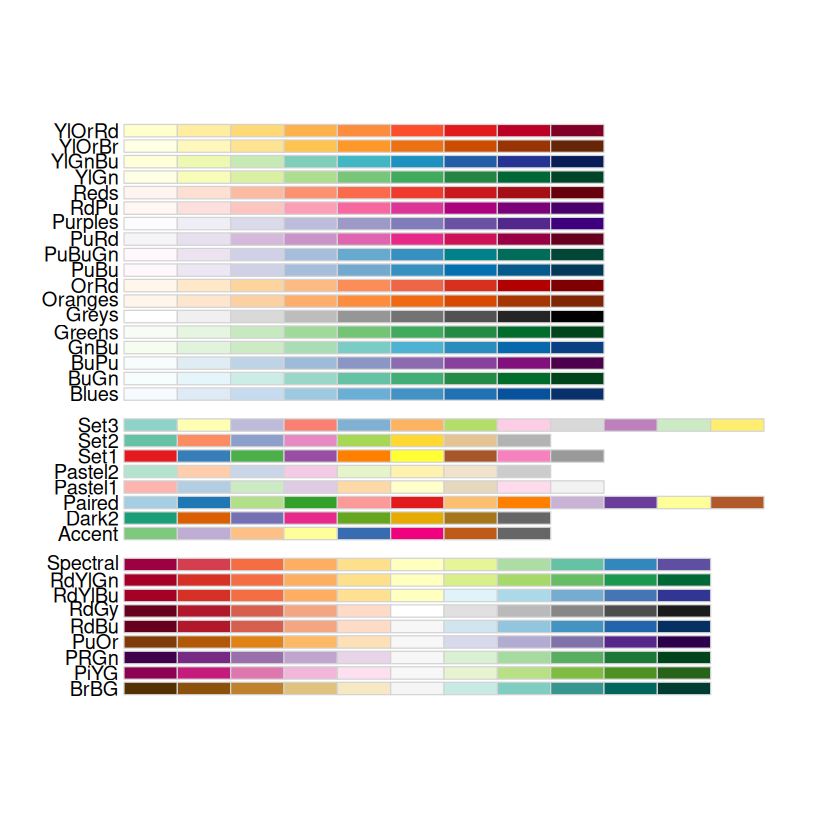

In [26]:
display.brewer.all()

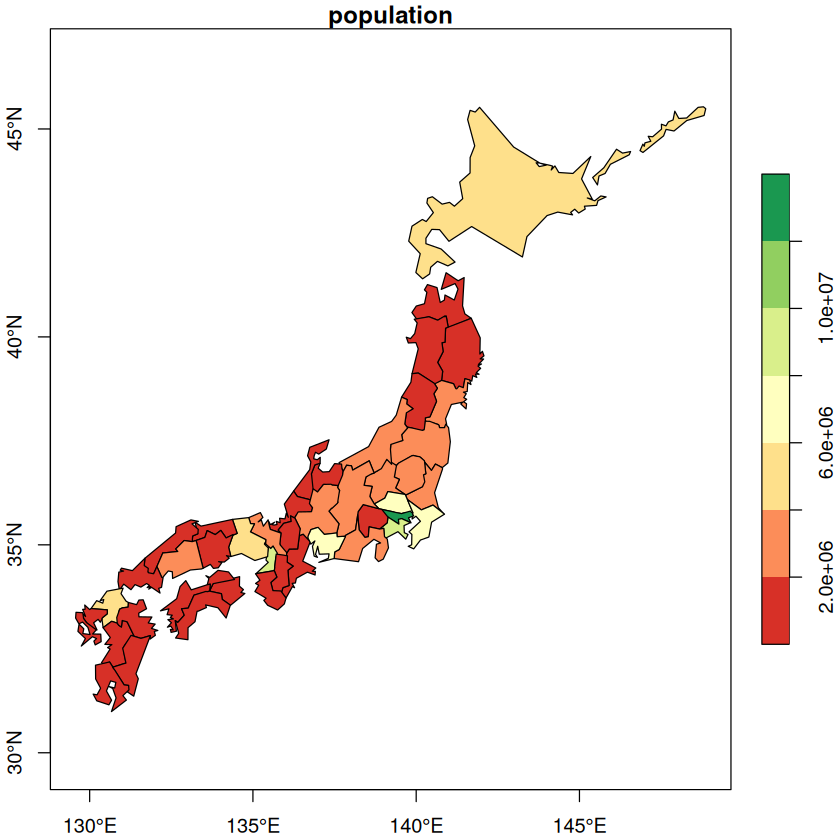

In [ ]:
nc <- 7
pal <- brewer.pal(nc, "RdYlGn")
plot(pref2[, "population"],pal=pal, axes=TRUE, nbreaks=nc)

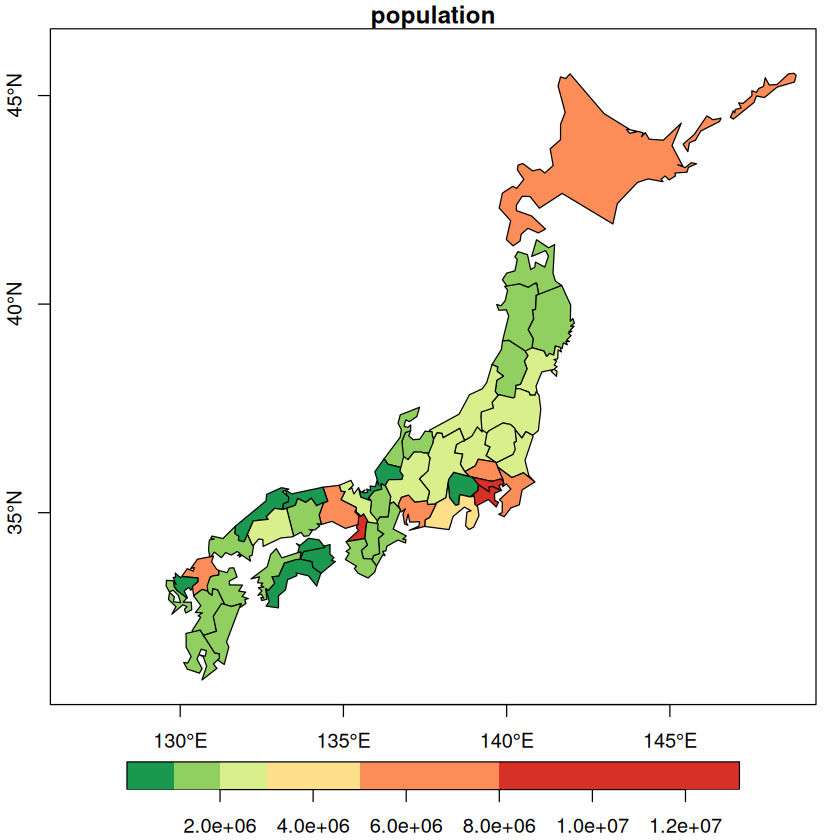

In [28]:
breaks <- c(0, 1000000, 2000000, 3000000, 5000000, 8000000, max(pref2$population))
nc <- length(breaks)-1
pal <- rev( brewer.pal(nc, "RdYlGn") )
plot(pref2[, "population"], pal=pal, axes=TRUE, xlim=c(130.5,145), ylim=c(31,46), breaks=breaks, key.pos=1, key.length=0.8)